In [ ]:
# Let's run Factor analysis and check for the underlysing factors
import pandas as pd
from sklearn.decomposition import FactorAnalysis
from sklearn.preprocessing import StandardScaler

# 1. Load the new dataset
df_survey = pd.read_csv("student_survey_fa.csv")

# 2. Standardize the data (Always important for FA and PCA!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_survey)

# 3. Initialize and fit Factor Analysis
fa = FactorAnalysis(n_components=2, random_state=42)
fa.fit(X_scaled)

# 4. Create a clean DataFrame to view the Factor Loadings
loadings = pd.DataFrame(
    fa.components_.T, columns=["Factor 1", "Factor 2"], index=df_survey.columns
)

print("NEW FACTOR ANALYSIS LOADINGS:")
print("=============================")
print(loadings.round(3))

NEW FACTOR ANALYSIS LOADINGS:
                           Factor 1  Factor 2
Q1_Coding_Skill               0.859    -0.181
Q2_Software_Adaptability      0.852    -0.161
Q3_Troubleshooting            0.875    -0.182
Q4_Study_Hours                0.189     0.830
Q5_Assignment_Punctuality     0.200     0.866
Q6_Class_Attendance           0.176     0.854


MODEL ADEQUACY TESTS:
Bartlett's Test Chi-Square : 5929.80
Bartlett's Test P-value    : 0.0000e+00
KMO Statistic              : 0.7556


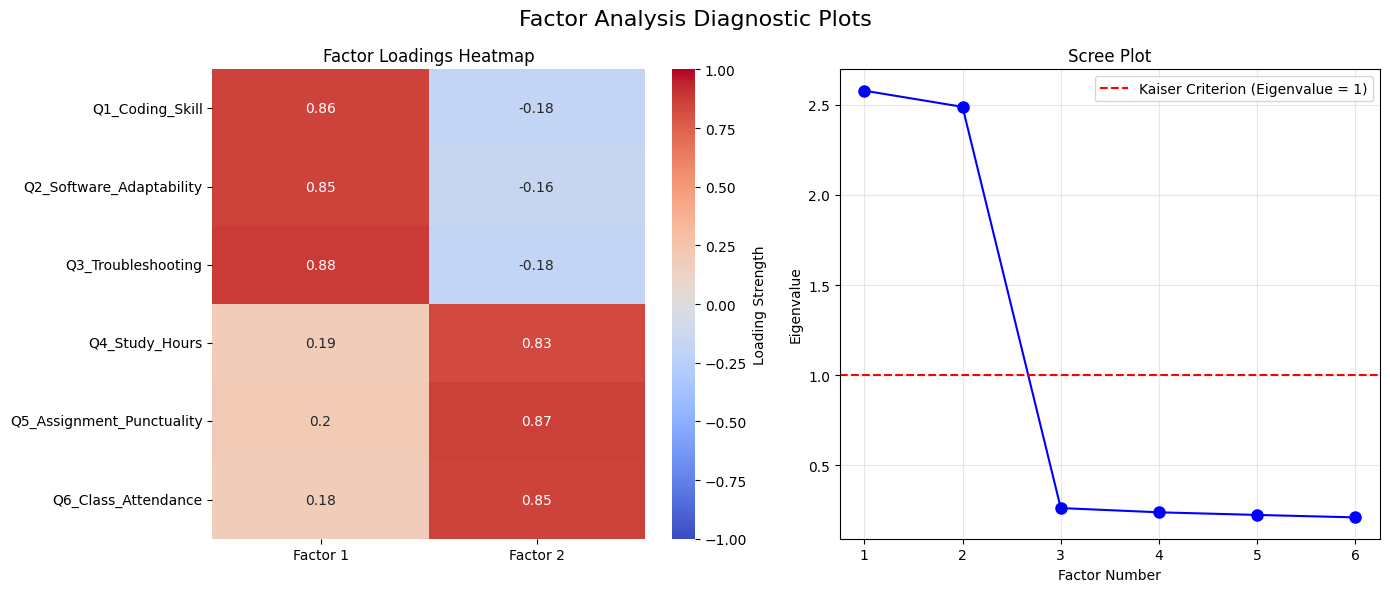

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import FactorAnalysis, PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2

# Load the dataset
df_survey = pd.read_csv("student_survey_fa.csv")

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_survey)

# --- 1. MODEL ADEQUACY TESTS ---
R = df_survey.corr().values
n = df_survey.shape[0]
p = df_survey.shape[1]

# Bartlett's Test
det_R = np.linalg.det(R)
chi2_stat = -(n - 1 - (2 * p + 5) / 6) * np.log(det_R)
df_chi2 = p * (p - 1) / 2
p_value = chi2.sf(chi2_stat, df_chi2)

# KMO Test
V = np.linalg.inv(R)
Q = np.zeros((p, p))
for i in range(p):
    for j in range(p):
        if i != j:
            Q[i, j] = -V[i, j] / np.sqrt(V[i, i] * V[j, j])
r_sq_sum = np.sum(R**2) - p
q_sq_sum = np.sum(Q**2)
kmo_stat = r_sq_sum / (r_sq_sum + q_sq_sum)

print("MODEL ADEQUACY TESTS:")
print("=" * 30)
print(f"Bartlett's Test Chi-Square : {chi2_stat:.2f}")
print(f"Bartlett's Test P-value    : {p_value:.4e}")
print(f"KMO Statistic              : {kmo_stat:.4f}")
print("=" * 30)

# --- 2. FACTOR ANALYSIS PLOTS ---
# Fit FA for the heatmap
fa = FactorAnalysis(n_components=2, random_state=42)
fa.fit(X_scaled)
loadings = pd.DataFrame(
    fa.components_.T, columns=["Factor 1", "Factor 2"], index=df_survey.columns
)

# Set up the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Factor Analysis Diagnostic Plots", fontsize=16)

# Plot 1: Heatmap of Factor Loadings
sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0],
    cbar_kws={"label": "Loading Strength"},
)
axes[0].set_title("Factor Loadings Heatmap")

# Plot 2: Scree Plot (Using PCA to get eigenvalues)
pca = PCA().fit(X_scaled)
eigenvalues = pca.explained_variance_
axes[1].plot(
    range(1, len(eigenvalues) + 1),
    eigenvalues,
    marker="o",
    linestyle="-",
    color="b",
    markersize=8,
)
axes[1].axhline(
    y=1, color="r", linestyle="--", label="Kaiser Criterion (Eigenvalue = 1)"
)
axes[1].set_title("Scree Plot")
axes[1].set_xlabel("Factor Number")
axes[1].set_ylabel("Eigenvalue")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fa_diagnostic_plots.png")

In [ ]:
# Model Adequacy Tests:
"""
Bartlett’s Test P-value: 0.0000 (Pass! The variables are significantly correlated, meaning there is something for the algorithm to find).

KMO Statistic: 0.7556 (Pass! This is "Middling/Good". A massive upgrade from the 0.49 we got on the previous dataset, meaning our variables definitely share underlying variance).
"""